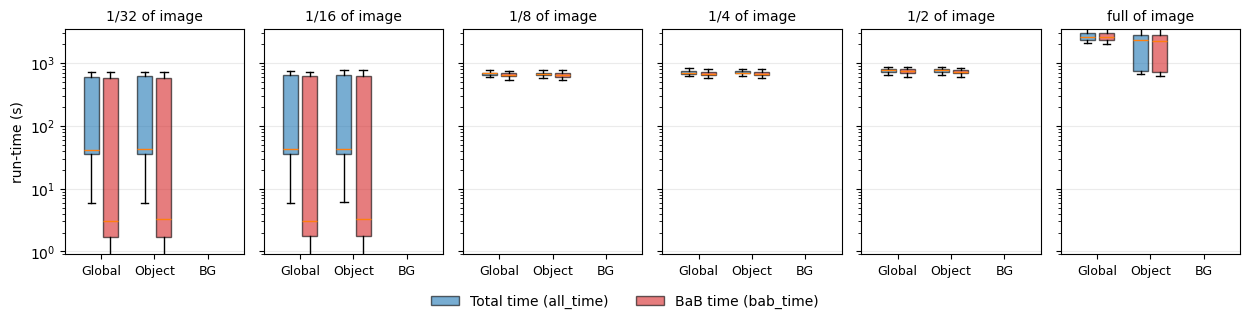

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =============================
# Load + tidy
# =============================
CSV_PATH = "csvs/ALL_vggnet_triplets_merged.csv"   # <- change
OUT_DIR  = "pdfs"                                 # <- change

df = pd.read_csv(CSV_PATH)

TAG2SEM = {
    "global": "Global",
    "fix_nonmask": "Object",
    "fix_mask": "Background",
}
df["Semantic"] = df["tag"].map(TAG2SEM).fillna(df["tag"].astype(str))

for c in ["k", "eps", "all_time", "bab_time"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["k", "eps", "all_time", "bab_time"])
df = df[(df["all_time"] > 0) & (df["bab_time"] > 0)]

SEM_ORDER = ["Global", "Object", "BG"]


# =============================
# Map k → fraction label
# =============================
FULL_K = df["k"].max()

def k_to_fraction(k):
    ratio = FULL_K / k
    if ratio == 1:
        return "full"
    return f"1/{int(ratio)}"


# =============================
# Plot
# =============================
def plot_all_vs_bab(df, eps_value=0.0001):

    dfx = df[df["eps"] == eps_value].copy()
    k_values = sorted(dfx["k"].unique())

    n = len(k_values)
    fig, axes = plt.subplots(1, n, figsize=(2.1*n, 3.2), sharey=True)

    if n == 1:
        axes = [axes]

    # shared y-limits
    yvals = np.concatenate([dfx["all_time"].values, dfx["bab_time"].values])
    yvals = yvals[yvals > 0]
    ylo = np.percentile(yvals, 1)
    yhi = np.percentile(yvals, 99)

    for i, k in enumerate(k_values):
        ax = axes[i]
        d_k = dfx[dfx["k"] == k]

        centers = np.arange(1, 4)
        dx = 0.18

        data_all = []
        data_bab = []

        for sem in SEM_ORDER:
            s_all = d_k[d_k["Semantic"] == sem]["all_time"]
            s_bab = d_k[d_k["Semantic"] == sem]["bab_time"]
            data_all.append(s_all.values)
            data_bab.append(s_bab.values)

        bp1 = ax.boxplot(
            data_all,
            positions=centers - dx,
            widths=0.28,
            patch_artist=True,
            showfliers=False
        )

        bp2 = ax.boxplot(
            data_bab,
            positions=centers + dx,
            widths=0.28,
            patch_artist=True,
            showfliers=False
        )

        for b in bp1["boxes"]:
            b.set_facecolor("C0")
            b.set_alpha(0.6)

        for b in bp2["boxes"]:
            b.set_facecolor("C3")
            b.set_alpha(0.6)

        ax.set_xticks(centers)
        ax.set_xticklabels(SEM_ORDER, fontsize=9)

        ax.set_yscale("log")
        ax.set_ylim(ylo, yhi)

        frac_label = k_to_fraction(k)
        ax.set_title(f"{frac_label} of image", fontsize=10)

        ax.grid(axis="y", alpha=0.25)

        if i == 0:
            ax.set_ylabel("run-time (s)")

    legend_handles = [
        Patch(facecolor="C0", edgecolor="black", alpha=0.6, label="Total time (all_time)"),
        Patch(facecolor="C3", edgecolor="black", alpha=0.6, label="BaB time (bab_time)")
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.tight_layout(rect=[0, 0.07, 1, 1])

    fig.savefig(os.path.join(OUT_DIR, "all_vs_bab_by_k_fraction.pdf"), bbox_inches="tight")

    plt.show()


# =============================
# Run
# =============================
plot_all_vs_bab(df, eps_value=0.0001)